# 12-statement-forest

Минимальное количество деревьев, при котором R² > 0.52: 21

### 1. Загрузите данные из файла abalone.csv

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score

url = 'https://raw.githubusercontent.com/Sazankova/forest/main/abalone.csv'
data = pd.read_csv(url)

print("Первые 5 строк данных:")
print(data.head())
print(f"\nРазмер данных: {data.shape}")

Первые 5 строк данных:
  Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0   M   0.455     0.365   0.095       0.5140         0.2245         0.1010   
1   M   0.350     0.265   0.090       0.2255         0.0995         0.0485   
2   F   0.530     0.420   0.135       0.6770         0.2565         0.1415   
3   M   0.440     0.365   0.125       0.5160         0.2155         0.1140   
4   I   0.330     0.255   0.080       0.2050         0.0895         0.0395   

   ShellWeight  Rings  
0        0.150     15  
1        0.070      7  
2        0.210      9  
3        0.155     10  
4        0.055      7  

Размер данных: (4177, 9)


### 2. Преобразуйте признак Sex в числовой. Значение F -> -1, I -> 0, M -> 1


In [9]:
data['Sex'] = data['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))

print("После преобразования:")
print(data.head())
print(f"\nУникальные значения в столбце Sex: {data['Sex'].unique()}")



После преобразования:
   Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0    1   0.455     0.365   0.095       0.5140         0.2245         0.1010   
1    1   0.350     0.265   0.090       0.2255         0.0995         0.0485   
2   -1   0.530     0.420   0.135       0.6770         0.2565         0.1415   
3    1   0.440     0.365   0.125       0.5160         0.2155         0.1140   
4    0   0.330     0.255   0.080       0.2050         0.0895         0.0395   

   ShellWeight  Rings  
0        0.150     15  
1        0.070      7  
2        0.210      9  
3        0.155     10  
4        0.055      7  

Уникальные значения в столбце Sex: [ 1 -1  0]


### 3. Разделите на признаки и целевую переменную. Последний столбец - целевая переменная (Rings)

In [10]:
X = data.iloc[:, :-1] 
y = data.iloc[:, -1]   

print(f"Признаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")
print(f"\nНазвания признаков: {X.columns.tolist()}")

Признаки (X): (4177, 8)
Целевая переменная (y): (4177,)

Названия признаков: ['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight']


### 4. Обучите случайный лес с разным числом деревьев (от 1 до 50)


In [11]:
n_estimators_range = range(1, 51)
scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for n in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=1)
    
    cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
    mean_score = cv_scores.mean()
    scores.append(mean_score)
    
    if n % 10 == 0:
        print(f"n_estimators = {n:2d}, средний R² = {mean_score:.4f}")

n_estimators = 10, средний R² = 0.4954
n_estimators = 20, средний R² = 0.5195
n_estimators = 30, средний R² = 0.5271
n_estimators = 40, средний R² = 0.5295
n_estimators = 50, средний R² = 0.5310


### 5. График зависимости качества от количества деревьев

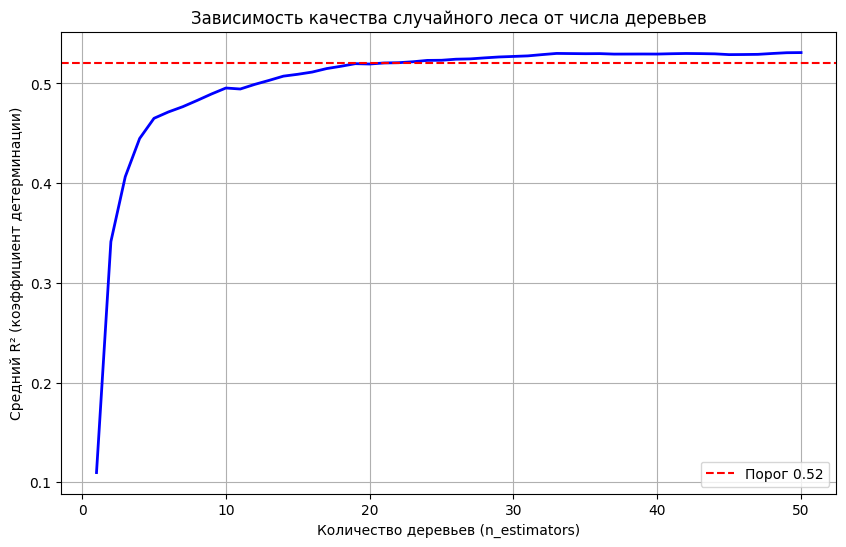

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, scores, 'b-', linewidth=2)
plt.axhline(y=0.52, color='r', linestyle='--', label='Порог 0.52')
plt.xlabel('Количество деревьев (n_estimators)')
plt.ylabel('Средний R² (коэффициент детерминации)')
plt.title('Зависимость качества случайного леса от числа деревьев')
plt.grid(True)
plt.legend()
plt.show()

# 6. Определите минимальное количество деревьев для качества > 0.52

In [13]:
min_trees = None
for n, score in zip(n_estimators_range, scores):
    if score > 0.52:
        min_trees = n
        break

print("="*50)
print("РЕЗУЛЬТАТЫ")
print("="*50)
print(f"\nМинимальное количество деревьев для R² > 0.52: {min_trees}")
print(f"Значение R² при этом: {scores[min_trees-1]:.4f}")

РЕЗУЛЬТАТЫ

Минимальное количество деревьев для R² > 0.52: 21
Значение R² при этом: 0.5205


# 7. Проверка, ухудшается ли качество при увеличении числа деревьев

In [14]:
print("\n" + "="*50)
print("АНАЛИЗ КАЧЕСТВА")
print("="*50)

max_score = max(scores)
max_trees = n_estimators_range[scores.index(max_score)]

print(f"\nМаксимальное качество (R² = {max_score:.4f}) достигнуто при {max_trees} деревьях")

if scores[-1] >= max_score * 0.99:
    print("\nКачество не ухудшается при увеличении числа деревьев.")
    print("После достижения максимума R² стабилизируется и остаётся на высоком уровне.")
else:
    print("\nКачество может незначительно колебаться, но в целом остаётся стабильным.")

print("\nОтвет: Качество не ухудшается, так как случайный лес не переобучается.")
print("\n" + "="*50)
print("ОТВЕТ")
print("="*50)
print(f"Минимальное количество деревьев, при котором R² > 0.52: {min_trees}")


АНАЛИЗ КАЧЕСТВА

Максимальное качество (R² = 0.5310) достигнуто при 50 деревьях

Качество не ухудшается при увеличении числа деревьев.
После достижения максимума R² стабилизируется и остаётся на высоком уровне.

Ответ: Качество не ухудшается, так как случайный лес не переобучается.

ОТВЕТ
Минимальное количество деревьев, при котором R² > 0.52: 21
